# Demonstration of modulation effects

In [1]:
# We start with some imports
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from constants import DEFAULT_SAMPLE_RATE
from engine import ModulatedFrequency
from engine import (
    TriangleOscillator, ModulatedPanner, Panner, ADSREnvelope, WaveAdder,
    SawtoothOscillator, ModulatedOscillator,
    Chain, ModulatedVolume, SineOscillator, SquareOscillator
)
from utils.utils import save_wave, note_to_frequency

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10


## Volume modulation with a low frequency oscillator

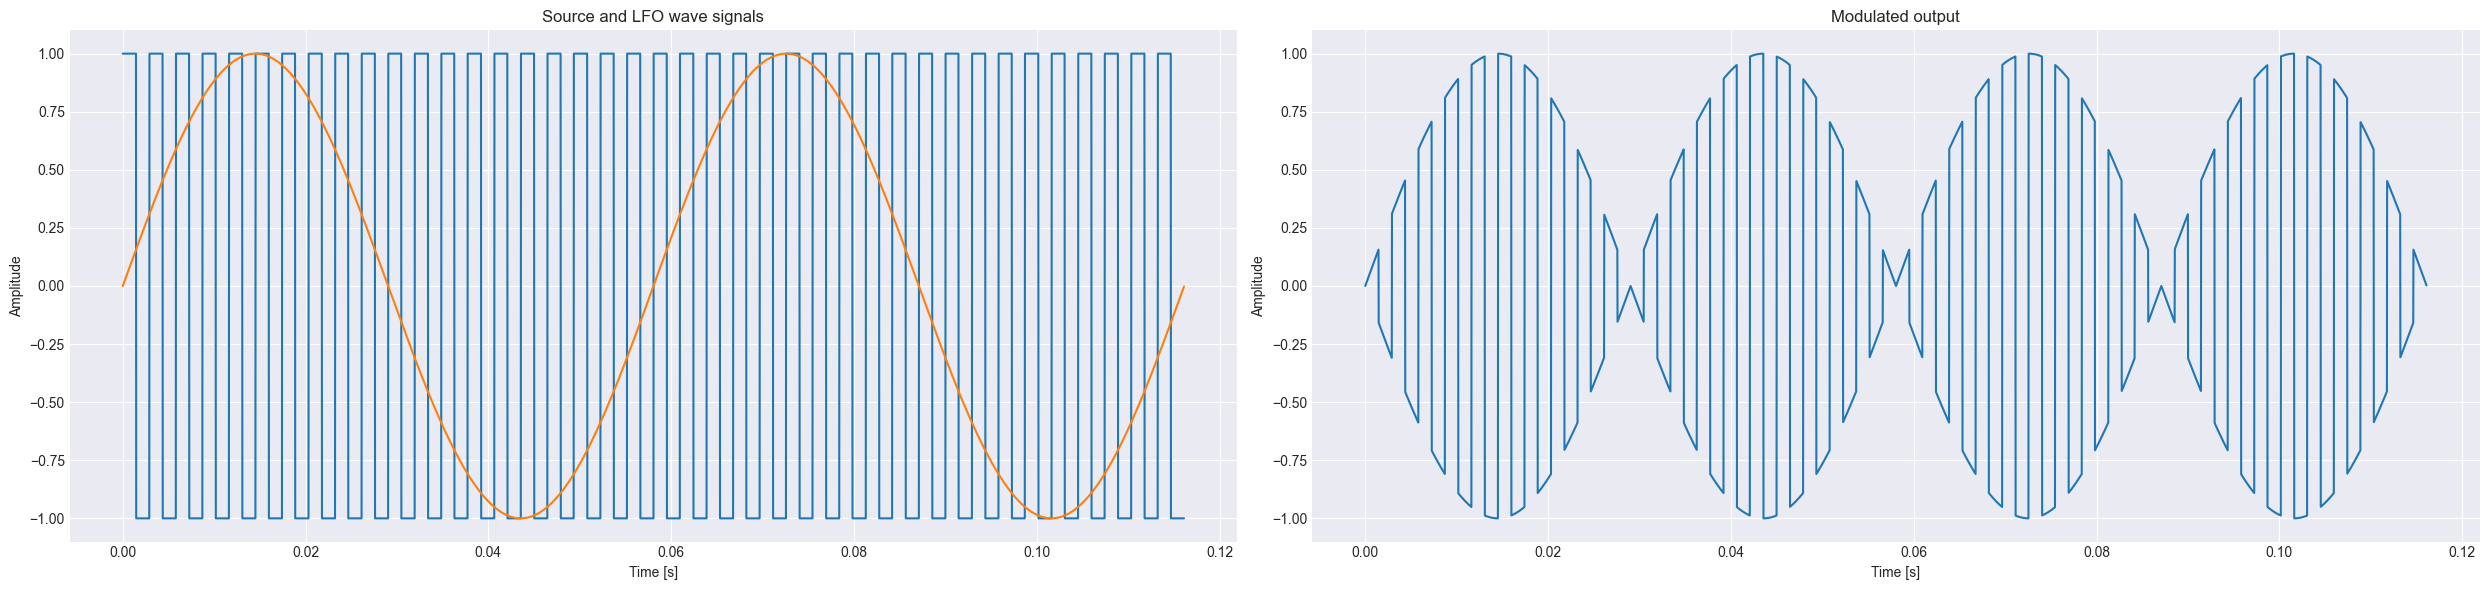

In [2]:
num_samples = 512 * 10
osc1 = SquareOscillator(frequency=4, amplitude=1, phase=0, sample_rate=num_samples / 10)

# Low frequency oscillator (LFO) for volume modulation
lfo = SineOscillator(frequency=0.2, amplitude=1, phase=0, sample_rate=num_samples / 10)
vol = ModulatedVolume(lfo)

# Chain them together
chain = Chain(osc1, vol)
chain_samples = chain.get_samples(n=num_samples)

duration = num_samples / DEFAULT_SAMPLE_RATE
time_axis = np.linspace(0, duration, num_samples)

fig, ax = plt.subplots(1, 2, figsize=(25, 6))
ax[0].set_title("Source and LFO wave signals")
ax[0].set_ylabel("Amplitude")
ax[0].set_xlabel("Time [s]")
ax[0].plot(time_axis, osc1.get_samples(n=num_samples))
ax[0].plot(time_axis, lfo.get_samples(n=num_samples))

ax[1].set_title("Modulated output")
ax[1].set_ylabel("Amplitude")
ax[1].set_xlabel("Time [s]")
ax[1].plot(time_axis, chain_samples)
plt.tight_layout()
plt.show()

## Frequency modulation with a low frequency oscillator

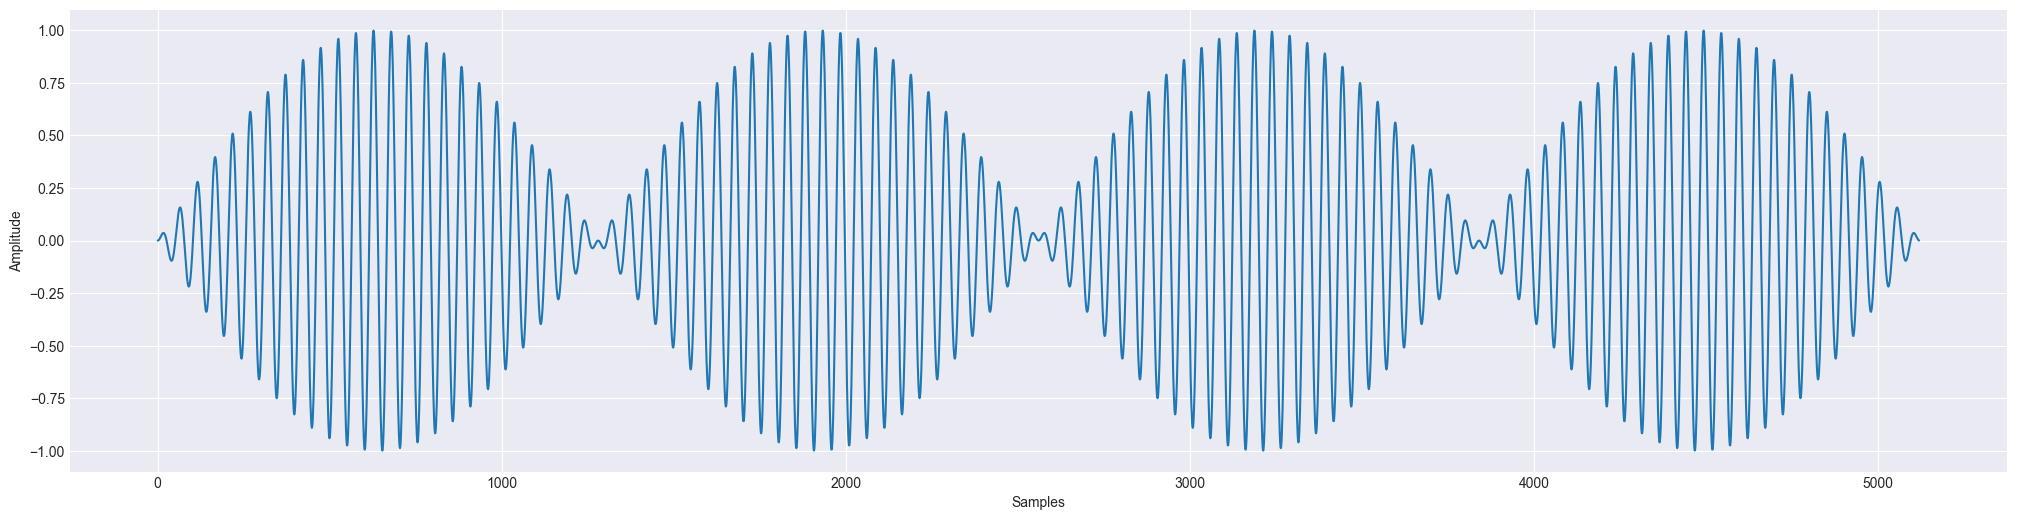

In [3]:
# Todo: fix frequency modulation via ModulatedFrequency class. Not yet working properly

osc1 = SineOscillator(frequency=10, amplitude=1, phase=0, sample_rate=512)

# Create a low frequency oscillator (LFO) for volume modulation
lfo = SineOscillator(frequency=0.2, amplitude=1, phase=0, sample_rate=512)
freq_mod = ModulatedFrequency(lfo)

fig, ax = plt.subplots(1, 1, figsize=(25, 6))
chain = Chain(osc1, freq_mod)
samples = chain.get_samples(n=512 * 10)
plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

## Frequency modulation using a Modulated Oscillator given a callable

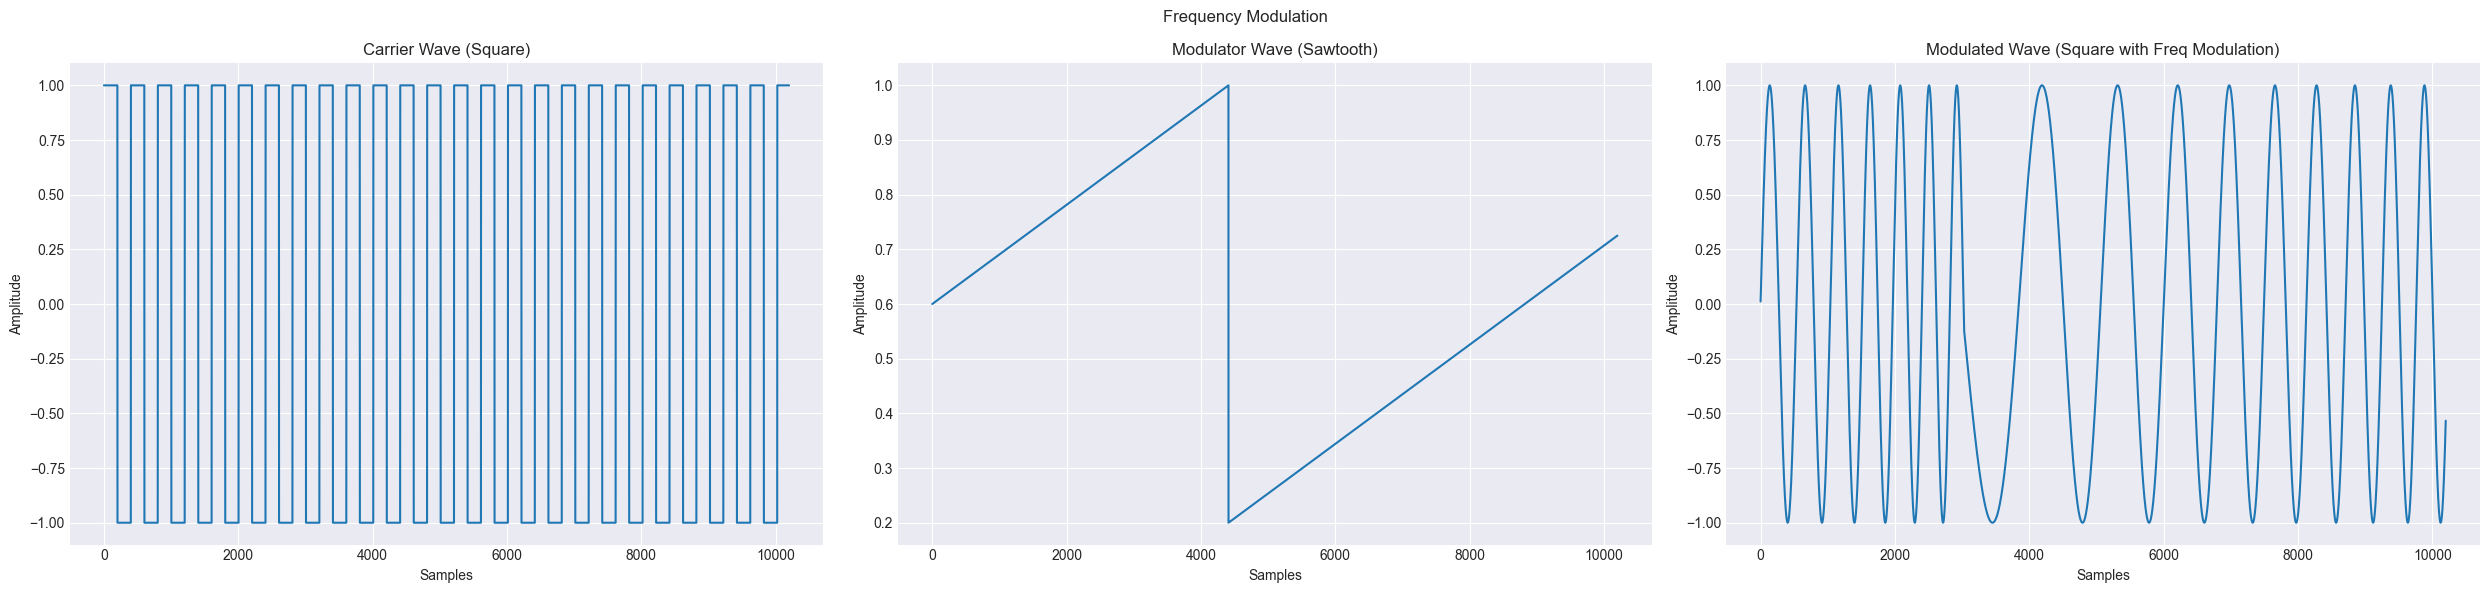

In [4]:
def freq_mod(init_freq, val):
    return init_freq * val

gen = ModulatedOscillator(
    SquareOscillator(frequency=110),
    SawtoothOscillator(frequency=5, wave_range=(0.2, 1)),
    freq_mod=freq_mod,
)

num_samples = int(512 / 5) * 100
carrier = gen.oscillator.get_samples(num_samples)
modulator = gen.modulators[0].get_samples(num_samples)
modulated = gen.get_samples(num_samples)

_, ax = plt.subplots(1, 3, figsize=(25, 6))
plt.suptitle("Frequency Modulation")
ax[0].plot(carrier)
ax[0].set_title("Carrier Wave (Square)")
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Amplitude")

ax[1].plot(modulator)
ax[1].set_title("Modulator Wave (Sawtooth)")
ax[1].set_xlabel("Samples")
ax[1].set_ylabel("Amplitude")

ax[2].plot(modulated)
ax[2].set_title("Modulated Wave (Square with Freq Modulation)")
ax[2].set_xlabel("Samples")
ax[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

## Modulation example

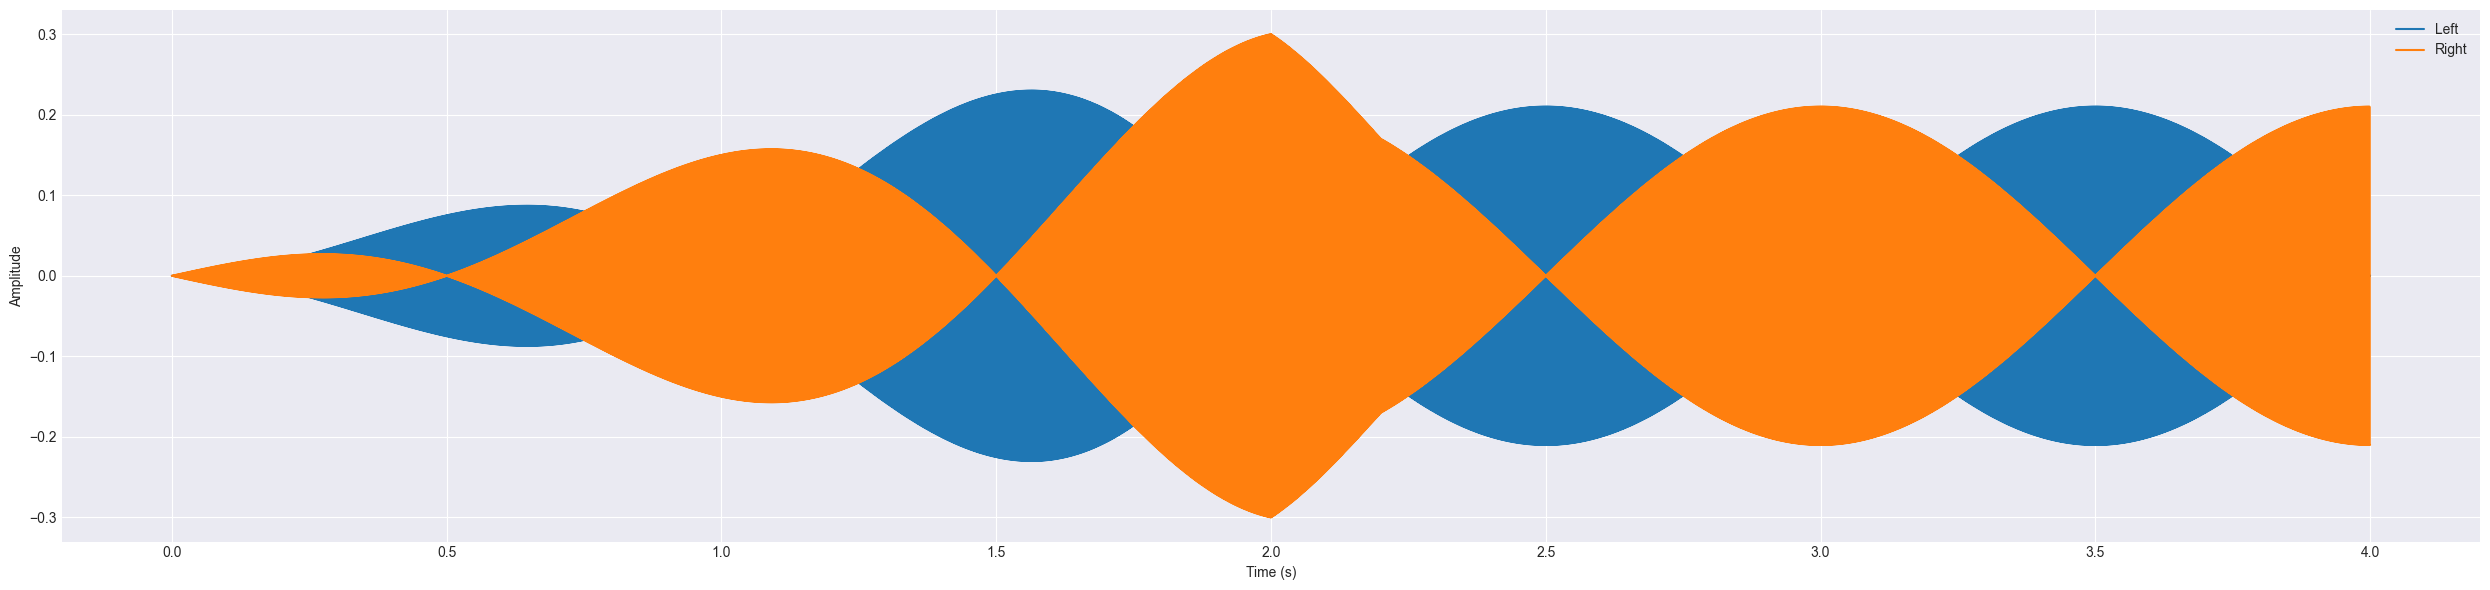

In [8]:
gen_simple = Chain(
    SquareOscillator(note_to_frequency("C5"), amplitude=0.3),
    ModulatedVolume(
        ADSREnvelope(attack_duration=2, decay_duration=0.2, sustain_level=0.7)
    ),
    ModulatedPanner(TriangleOscillator(1, phase=180, wave_range=(-1, 1))),
)

num_samples = DEFAULT_SAMPLE_RATE * 4
duration = num_samples / DEFAULT_SAMPLE_RATE
time = np.linspace(0, duration, num_samples)
l, r = gen_simple.get_samples(num_samples).T

_, ax = plt.subplots(1, 1, figsize=(25, 6))
ax.plot(time, l, label="Left")
ax.plot(time, r, label="Right")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.tight_layout()
plt.show()

save_wave(l, r, filename="simple_mod.wav")
display(Audio(filename="simple_mod.wav", rate=DEFAULT_SAMPLE_RATE))

## Modulated example

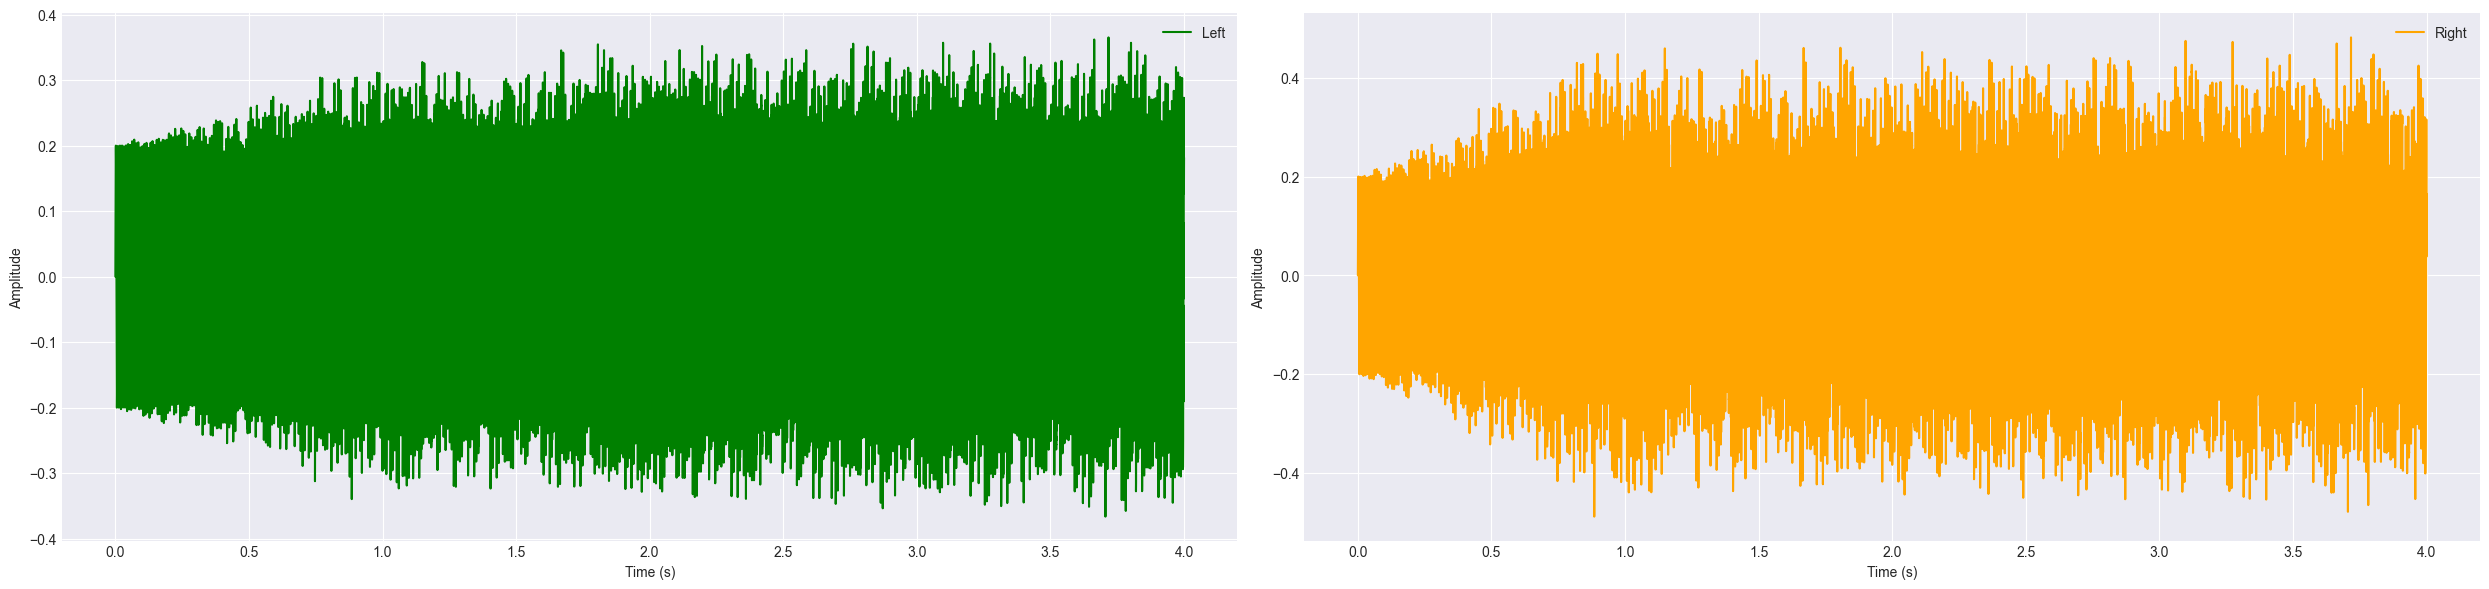

In [9]:
def amp_mod(init_amp, env):
    return env * init_amp

gen = WaveAdder(
    Chain(
        SquareOscillator(note_to_frequency("C5"), amplitude=0.3),
        ModulatedVolume(
            ADSREnvelope(attack_duration=2, decay_duration=0.001, sustain_level=1)
        ),
        ModulatedPanner(TriangleOscillator(1, phase=180, wave_range=(-1, 1))),
    ),
    Chain(
        SquareOscillator(note_to_frequency("A5"), amplitude=0.3),
        ModulatedVolume(
            ADSREnvelope(attack_duration=2, decay_duration=0.001, sustain_level=1)
        ),
        ModulatedPanner(TriangleOscillator(1, wave_range=(-1, 1))),
    ),
    Chain(
        ModulatedOscillator(
            SawtoothOscillator(note_to_frequency("A4"), amplitude=0.8),
            SineOscillator(10, wave_range=(0.9, 1)),
            freq_mod=amp_mod,
        ),
        ModulatedVolume(ADSREnvelope(1)),
        Panner(0.3),
    ),
    Chain(
        ModulatedOscillator(
            SawtoothOscillator(note_to_frequency("C4"), amplitude=0.8),
            SineOscillator(10, wave_range=(0.9, 1)),
            freq_mod=amp_mod,
        ),
        ModulatedVolume(ADSREnvelope(1)),
        Panner(0.7),
    ),
    SineOscillator(note_to_frequency("C3")),
    stereo=True,
)

num_samples = DEFAULT_SAMPLE_RATE * 4
duration = num_samples / DEFAULT_SAMPLE_RATE
time = np.linspace(0, duration, num_samples)
left, right = gen.get_samples(num_samples).T

_, ax = plt.subplots(1, 2, figsize=(25, 6))
ax[0].plot(time, left, label="Left", color="green")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].legend()

ax[1].plot(time, right, label="Right", color="orange")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude")
ax[1].legend()
plt.tight_layout()
plt.show()

save_wave(left, right, filename="prelude.wav")
display(Audio("prelude.wav", rate=DEFAULT_SAMPLE_RATE))


## Additional example

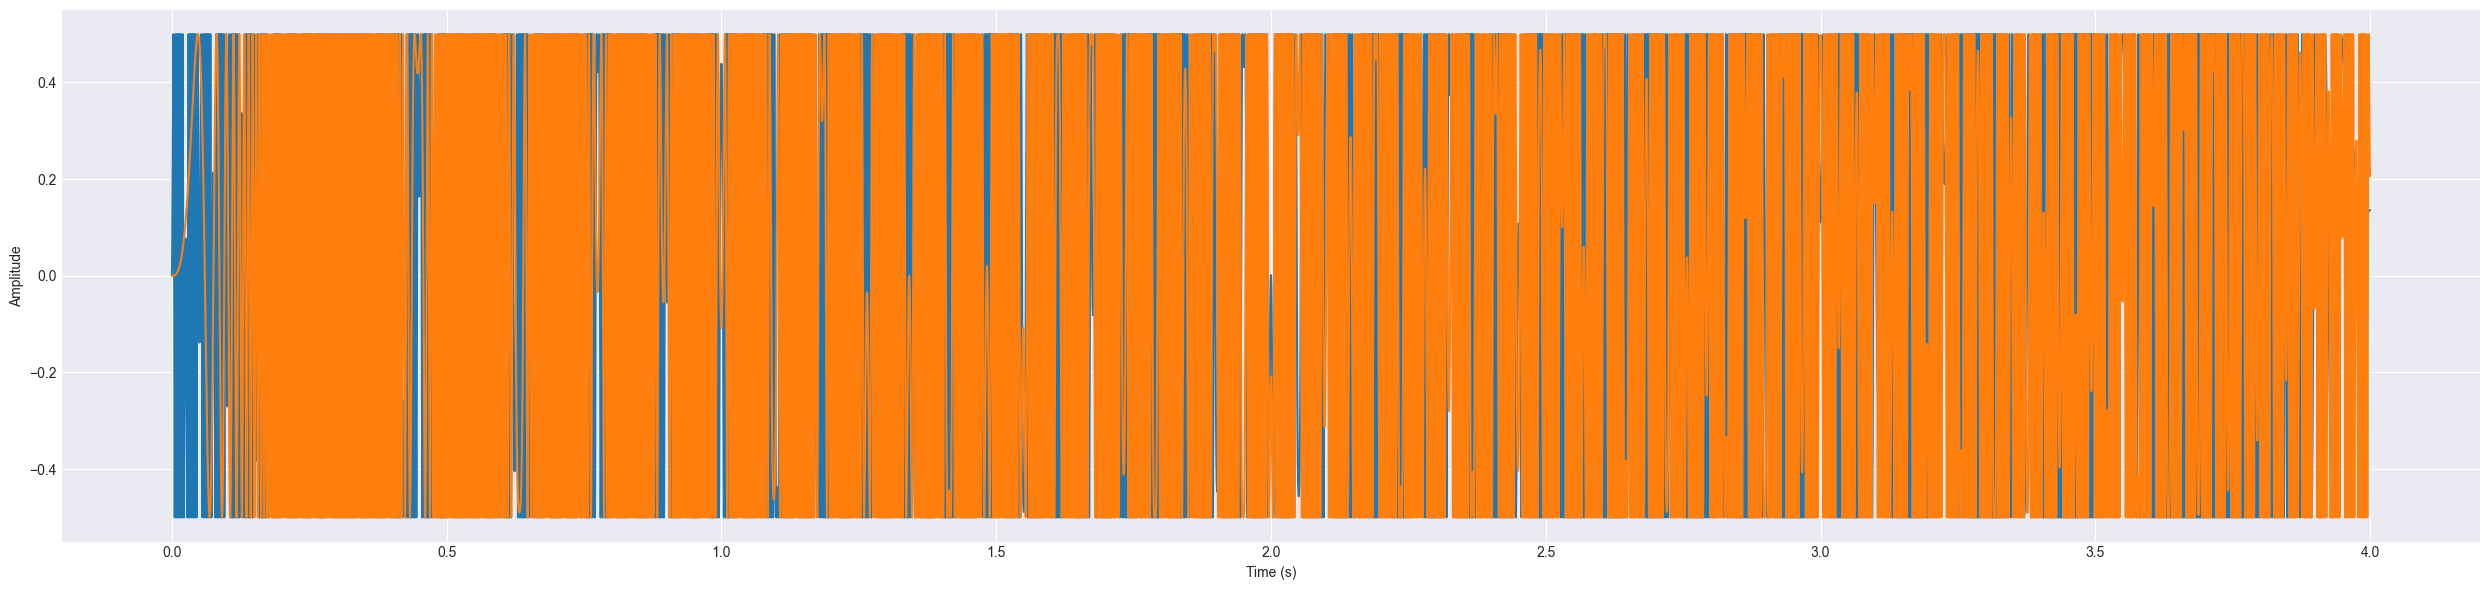

In [7]:
gen = Chain(
    WaveAdder(
        Chain(
            ModulatedOscillator(
                SineOscillator(note_to_frequency("A4")),
                ModulatedOscillator(
                    SineOscillator(20), ADSREnvelope(0, 4, 0), freq_mod=amp_mod
                ),
                freq_mod=freq_mod,
            ),
            Panner(-1),
        ),
        Chain(
            ModulatedOscillator(
                SineOscillator(note_to_frequency("A4")),
                ModulatedOscillator(
                    SineOscillator(20), ADSREnvelope(4), freq_mod=amp_mod
                ),
                freq_mod=freq_mod,
            ),
            Panner(1),
        ),
        stereo=True,
    )
)

num_samples = DEFAULT_SAMPLE_RATE * 4
duration = num_samples / DEFAULT_SAMPLE_RATE
time = np.linspace(0, duration, num_samples)
amplitude = gen.get_samples(num_samples)

_, ax = plt.subplots(1, 1, figsize=(25, 6))
ax.plot(time, amplitude)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
plt.tight_layout()

save_wave(amplitude, filename="accel_decel.wav")
display(Audio(filename="accel_decel.wav", rate=DEFAULT_SAMPLE_RATE))